In [1]:
#If running locally instead of colab
DATA_PATH = 'cleaned_data'

# Task 4.1

**4.1 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 28

In [2]:
TARGET_COL = 'HAI_H1N1 A/Victoria/4897/2022_d28'  # task 4.1

## Task 4.1: BASELINE LINNEAR REGRESSION MODEL
Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for H1N1 A/Victoria/4897/2022 at Day 28 post-vaccination.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

train_hai = train_hai[['participant_id']+['HAI_H1N1 A/Victoria/4897/2022_d0']+[TARGET_COL]]

In [5]:
for name, df in {'train_hai': train_hai, 'train_participants': train_participants}.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(df.head(5))


TABLE: train_hai


,participant_id,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H1N1 A/Victoria/4897/2022_d28
0,2016_UGA.ID_001,NaN,NaN
1,2016_UGA.ID_002,NaN,NaN
2,2016_UGA.ID_003,NaN,NaN
3,2016_UGA.ID_004,NaN,NaN
4,2016_UGA.ID_005,NaN,NaN



TABLE: train_participants


,participant_id,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age
0,SDY269.SUB112836,Female,White,Georgia,Other,28.0
1,SDY269.SUB112849,Female,Black,Georgia,Other,39.0
2,SDY269.SUB112854,Male,Black,Georgia,Other,46.0
3,SDY269.SUB112860,Female,White,Georgia,Other,32.0
4,SDY269.SUB112881,Female,Black,Georgia,Other,29.0


### Data is pre-cleaned
Both tables are already one row per participant with cleaned column names:
- HAI columns follow `HAI_{strain}_d{timepoint}` format
- Participant columns follow `PART_{field}` format

We just need to merge them and separate features from target.

In [6]:
# Merge HAI and participant tables
data = train_hai.merge(train_participants, on='participant_id', how='inner')
print(f'Merged shape: {data.shape}')
data.head()

Merged shape: (3757, 8)


,participant_id,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H1N1 A/Victoria/4897/2022_d28,PART_biological_sex,PART_race,PART_geolocation,PART_arm_name,PART_age
0,2016_UGA.ID_001,NaN,NaN,Female,Unknown,Georgia,Standard Fluzone,29.0
1,2016_UGA.ID_002,NaN,NaN,Female,Unknown,Georgia,Standard Fluzone,29.0
2,2016_UGA.ID_003,NaN,NaN,Female,Unknown,Georgia,Standard Fluzone,28.0
3,2016_UGA.ID_004,NaN,NaN,Male,Unknown,Georgia,Standard Fluzone,27.0
4,2016_UGA.ID_005,NaN,NaN,Female,Unknown,Georgia,Standard Fluzone,25.0


In [7]:
# Features: only d0 HAI columns + participant columns (no future data)
feature_cols = [c for c in data.columns
                if c != 'participant_id'
                and c != TARGET_COL
                and not c.endswith('_d28')
                and not c.endswith('_d365')]

print(f'Target: {TARGET_COL}')
print(f'Features: {len(feature_cols)}')
print(f'Sample feature names: {feature_cols[:5]}')

Target: HAI_H1N1 A/Victoria/4897/2022_d28
Features: 6
Sample feature names: ['HAI_H1N1 A/Victoria/4897/2022_d0', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']


### Build X and y

In [8]:
# Target: single strain HAI titer at Day 28
y_vals = data[TARGET_COL].copy()

# Drop rows where target is NaN
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

print(f'Samples: {len(X)}')
print(f'Features: {X.shape[1]}')

Samples: 212
Features: 6


### Encode categorical features

In [9]:
# One-hot encode any categorical PART_ columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print(f'Encoding categorical columns: {cat_cols}')
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'Final feature count: {X.shape[1]}')

Encoding categorical columns: ['PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Final feature count: 4


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_23559/398821456.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [10]:
#Drop any columns with more than 40% null values and print all dropped columns
def drop_null_columns(df, threshold=0.4):
    null_counts = df.isnull().sum()
    total_rows = len(df)
    null_percentages = null_counts / total_rows
    columns_to_drop = null_percentages[null_percentages > threshold].index
    df = df.drop(columns=columns_to_drop)
    print(f"Dropped columns with more than {threshold * 100}% null values:")
    print(columns_to_drop)

drop_null_columns(X)


Dropped columns with more than 40.0% null values:
Index([], dtype='str')


In [11]:
X.head()

,HAI_H1N1 A/Victoria/4897/2022_d0,PART_age,PART_biological_sex_Male,PART_arm_name_Standard Fluzone
1544,2.321928,46.0,True,True
1545,2.321928,68.0,False,False
1546,2.321928,28.0,False,True
1547,2.321928,63.0,False,True
1548,2.321928,30.0,False,True


In [12]:
#Standard scale PART_age

scaler = StandardScaler()
X['PART_age'] = scaler.fit_transform(X[['PART_age']])
X.head()

,HAI_H1N1 A/Victoria/4897/2022_d0,PART_age,PART_biological_sex_Male,PART_arm_name_Standard Fluzone
1544,2.321928,-0.487221,True,True
1545,2.321928,0.747778,False,False
1546,2.321928,-1.497674,False,True
1547,2.321928,0.467096,False,True
1548,2.321928,-1.385401,False,True


In [13]:
# X and y are ready — proceed to training

### Train model

**Why Spearman correlation?**

This task uses Spearman correlation as its evaluation metric. Spearman only cares about
**rankings**. It converts all your true values and predictions into ranks (1st, 2nd, 3rd…)
and then checks whether those two rank orderings agree.

This is a good fit for antibody data because:
- HAI titers are noisy and vary across studies, so predicting exact values is unrealistic.
- What matters clinically is *relative* response: can we identify who will respond well vs. poorly?
- Spearman is also robust to outliers and non-linear relationships — if your predictions are
  monotonically related to the truth (always going in the right direction), Spearman rewards that
  even if the relationship isn't a straight line.

**Interpreting the score:**
A Spearman of 1.0 means perfect ranking agreement, 0.0 means no relationship, and -1.0 means
perfectly reversed rankings.

In [14]:
# Simple pipeline: impute remaining NaNs, then regress
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Cross-validated evaluation (the real score) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y_vals, cv=cv)
rho_cv, pval_cv = spearmanr(y_vals, y_pred_cv)
print(f'Spearman (5-fold CV): {rho_cv:.3f}  (p-value: {pval_cv:.4f})')

Spearman (5-fold CV): 0.339  (p-value: 0.0000)


### Why Cross-Validation?

The CV score above is our real evaluation. Each participant's prediction was made by a model
that **never saw that participant during training** (5-fold: train on 4/5 of the data, predict
the held-out 1/5, rotate). This tells us how the model would perform on new, unseen participants.

The train score is shown only as an overfitting diagnostic — a large gap between train and CV
means the model memorised noise rather than learning real patterns.

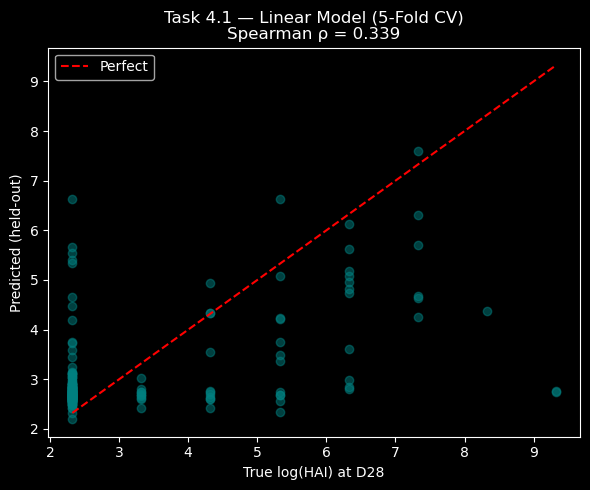

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals, y_pred_cv, alpha=0.5, color='teal')
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.1 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

### Next Steps

Use the linnear reg model to predict challenge set